# XGBoost Classifier for Bank Fraud Detection
This notebook trains an XGBoost model on cleaned fraud data and evaluates it using standardized metrics.

## 1. Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, average_precision_score, 
                             roc_auc_score, precision_recall_curve, f1_score, make_scorer)
from sklearn.feature_selection import SelectFromModel
from scipy.stats import uniform, randint
from xgboost.callback import EarlyStopping

## 2. Evaluation Function

In [4]:
def evaluate_model(y_true, y_pred, y_proba=None, plot_pr_curve=True):
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Key Metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    metrics = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm.tolist()
    }

    # Probabilistic metrics
    if y_proba is not None:
        pr_auc = average_precision_score(y_true, y_proba)
        metrics['auc_pr'] = pr_auc
        print(f"AUC-PR (Average Precision): {pr_auc:.4f}")

        roc_auc = roc_auc_score(y_true, y_proba)
        metrics['roc_auc'] = roc_auc
        print(f"ROC AUC:                   {roc_auc:.4f}")

        if plot_pr_curve:
            precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)
            plt.figure(figsize=(6, 5))
            plt.plot(recall_pts, precision_pts, marker='.', label='PR Curve')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return metrics

## 3. Load and Prepare Data

In [5]:
folds = []

for i in range(1, 6):
    val_df = pd.read_csv(f"../../data/preprocessed/fold_{i}_val.csv")
    train_dfs = []

    for j in range(1, 6):
        if j != i:
            train_dfs.append(pd.read_csv(f"../../data/preprocessed/fold_{j}_train.csv"))
    
    train_df = pd.concat(train_dfs, ignore_index=True)
    folds.append((train_df, val_df))

## 4. Train XGBoost Model with Hyperparameter Tuning & 5. Evaluate Model

### Version 1: Too Slow Run Time, will take ~10 hours


--- Fold 1 ---
Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best ROC-AUC Score from CV: 0.9993683102174383
Classification Report:
              precision    recall  f1-score   support

           0     0.9912    0.9992    0.9952    178712
           1     0.7043    0.1786    0.2850      1920

    accuracy                         0.9905    180632
   macro avg     0.8478    0.5889    0.6401    180632
weighted avg     0.9882    0.9905    0.9877    180632


Confusion Matrix:
[[178568    144]
 [  1577    343]]

Precision: 0.7043
Recall:    0.1786
F1 Score:  0.2850
AUC-PR (Average Precision): 0.4175
ROC AUC:                   0.9640


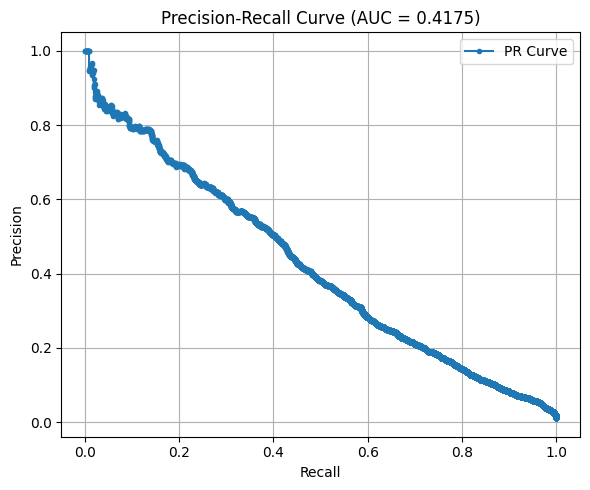


--- Fold 2 ---
Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best ROC-AUC Score from CV: 0.9993614300448339
Classification Report:
              precision    recall  f1-score   support

           0     0.9913    0.9989    0.9950    178711
           1     0.6304    0.1812    0.2814      1921

    accuracy                         0.9902    180632
   macro avg     0.8108    0.5900    0.6382    180632
weighted avg     0.9874    0.9902    0.9875    180632


Confusion Matrix:
[[178507    204]
 [  1573    348]]

Precision: 0.6304
Recall:    0.1812
F1 Score:  0.2814
AUC-PR (Average Precision): 0.3741
ROC AUC:                   0.9603


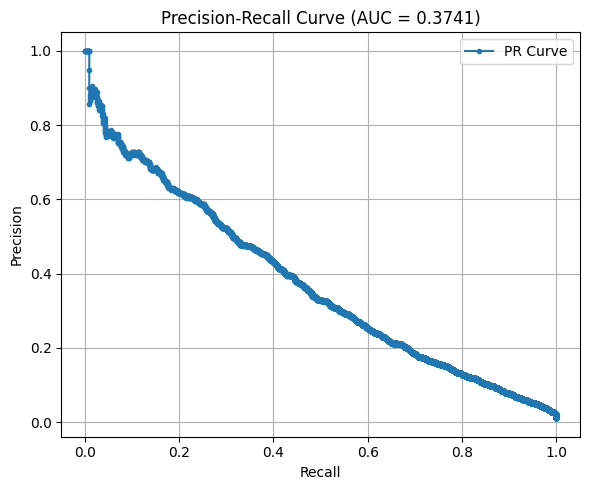


--- Fold 3 ---
Fitting 3 folds for each of 72 candidates, totalling 216 fits


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

for fold_idx, (train_df, val_df) in enumerate(folds, 1):
    print(f"\n--- Fold {fold_idx} ---")

    # Split features and labels
    X_train = train_df.drop(columns=['fraud_bool'])
    y_train = train_df['fraud_bool']
    
    X_val = val_df.drop(columns=['fraud_bool'])
    y_val = val_df['fraud_bool']

    # Base model for feature selection
    xgb_base = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
    xgb_base.fit(X_train, y_train)

    # Feature selection based on importance
    # selector = SelectFromModel(xgb_base, threshold='median', prefit=True)
    # X_train_selected = selector.transform(X_train)
    # X_val_selected = selector.transform(X_val)

    # Initialize and perform GridSearch
    xgb_clf = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
    grid_search = GridSearchCV(
        estimator=xgb_clf,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=3,
        verbose=1,
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    print("Best Parameters:", grid_search.best_params_)
    print("Best ROC-AUC Score from CV:", grid_search.best_score_)

    # Predict and evaluate on the validation set
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:, 1]

    evaluate_model(y_val, y_pred, y_prob)

In [5]:
import time

xgb_test = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
start = time.time()
xgb_test.fit(X_train, y_train)
print("Single fit time:", time.time() - start)


Single fit time: 42.06954097747803


### Version 2: Faster Run Time, will take ~20 minutes


--- Fold 1 ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'colsample_bytree': 0.893352578649596, 'learning_rate': 0.18198808134726413, 'max_depth': 7, 'n_estimators': 172, 'subsample': 0.813010318597056}
Best ROC-AUC Score from CV: 0.9989959347485264
Classification Report:
              precision    recall  f1-score   support

           0     0.9907    0.9988    0.9948    178712
           1     0.5417    0.1286    0.2079      1920

    accuracy                         0.9896    180632
   macro avg     0.7662    0.5637    0.6013    180632
weighted avg     0.9859    0.9896    0.9864    180632


Confusion Matrix:
[[178503    209]
 [  1673    247]]

Precision: 0.5417
Recall:    0.1286
F1 Score:  0.2079
AUC-PR (Average Precision): 0.2850
ROC AUC:                   0.9444


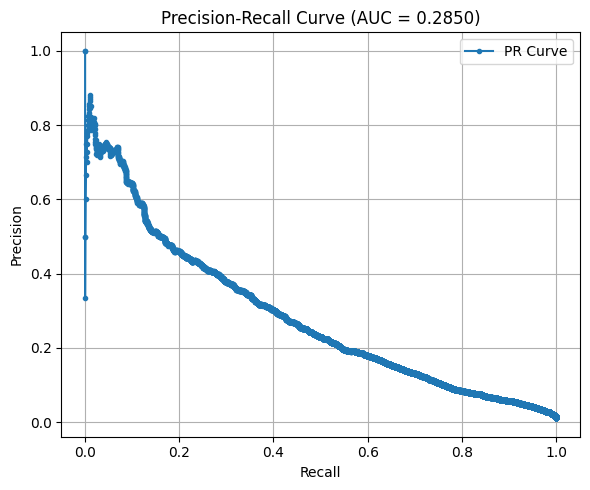


--- Fold 2 ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'colsample_bytree': 0.893352578649596, 'learning_rate': 0.18198808134726413, 'max_depth': 7, 'n_estimators': 172, 'subsample': 0.813010318597056}
Best ROC-AUC Score from CV: 0.9989653035895935
Classification Report:
              precision    recall  f1-score   support

           0     0.9908    0.9987    0.9947    178711
           1     0.5311    0.1379    0.2190      1921

    accuracy                         0.9895    180632
   macro avg     0.7609    0.5683    0.6069    180632
weighted avg     0.9859    0.9895    0.9865    180632


Confusion Matrix:
[[178477    234]
 [  1656    265]]

Precision: 0.5311
Recall:    0.1379
F1 Score:  0.2190
AUC-PR (Average Precision): 0.2915
ROC AUC:                   0.9470


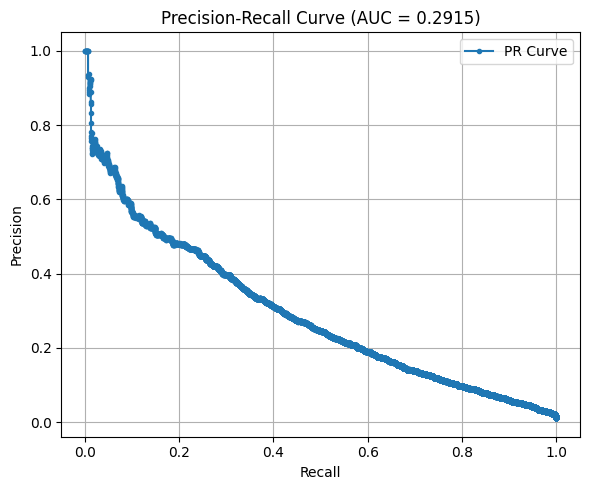


--- Fold 3 ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'colsample_bytree': 0.893352578649596, 'learning_rate': 0.18198808134726413, 'max_depth': 7, 'n_estimators': 172, 'subsample': 0.813010318597056}
Best ROC-AUC Score from CV: 0.9989914136417498
Classification Report:
              precision    recall  f1-score   support

           0     0.9907    0.9987    0.9947    178711
           1     0.5176    0.1302    0.2081      1920

    accuracy                         0.9895    180631
   macro avg     0.7542    0.5645    0.6014    180631
weighted avg     0.9857    0.9895    0.9863    180631


Confusion Matrix:
[[178478    233]
 [  1670    250]]

Precision: 0.5176
Recall:    0.1302
F1 Score:  0.2081
AUC-PR (Average Precision): 0.2807
ROC AUC:                   0.9439


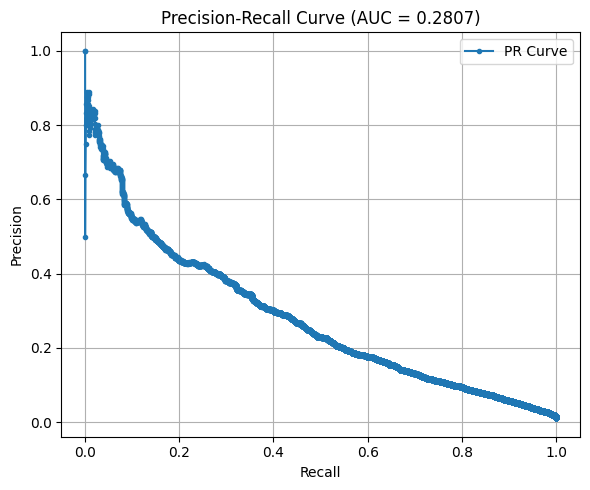


--- Fold 4 ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'colsample_bytree': 0.893352578649596, 'learning_rate': 0.18198808134726413, 'max_depth': 7, 'n_estimators': 172, 'subsample': 0.813010318597056}
Best ROC-AUC Score from CV: 0.9989822300133825
Classification Report:
              precision    recall  f1-score   support

           0     0.9908    0.9987    0.9947    178711
           1     0.5274    0.1354    0.2155      1920

    accuracy                         0.9895    180631
   macro avg     0.7591    0.5671    0.6051    180631
weighted avg     0.9859    0.9895    0.9864    180631


Confusion Matrix:
[[178478    233]
 [  1660    260]]

Precision: 0.5274
Recall:    0.1354
F1 Score:  0.2155
AUC-PR (Average Precision): 0.2812
ROC AUC:                   0.9443


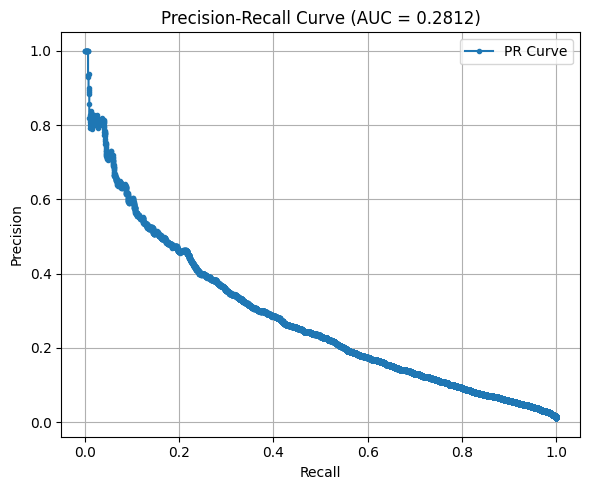


--- Fold 5 ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'colsample_bytree': 0.893352578649596, 'learning_rate': 0.18198808134726413, 'max_depth': 7, 'n_estimators': 172, 'subsample': 0.813010318597056}
Best ROC-AUC Score from CV: 0.9989821973956459
Classification Report:
              precision    recall  f1-score   support

           0     0.9908    0.9988    0.9948    178711
           1     0.5415    0.1359    0.2173      1920

    accuracy                         0.9896    180631
   macro avg     0.7661    0.5674    0.6060    180631
weighted avg     0.9860    0.9896    0.9865    180631


Confusion Matrix:
[[178490    221]
 [  1659    261]]

Precision: 0.5415
Recall:    0.1359
F1 Score:  0.2173
AUC-PR (Average Precision): 0.2923
ROC AUC:                   0.9416


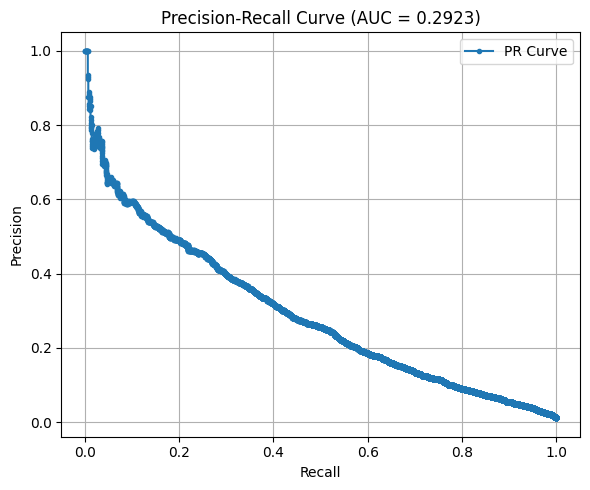

In [23]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
import xgboost as xgb

param_dist = {
    'n_estimators': randint(100, 201),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.8, 0.2),
    'colsample_bytree': uniform(0.8, 0.2)
}

subsample_frac = 0.2

for fold_idx, (train_df, val_df) in enumerate(folds, 1):
    print(f"\n--- Fold {fold_idx} ---")

    X_train_full = train_df.drop(columns=['fraud_bool'])
    y_train_full = train_df['fraud_bool']
    
    X_val = val_df.drop(columns=['fraud_bool'])
    y_val = val_df['fraud_bool']

    # Subsample for faster tuning
    X_train = X_train_full.sample(frac=subsample_frac, random_state=42)
    y_train = y_train_full.loc[X_train.index]

    # Initialize classifier
    xgb_clf = xgb.XGBClassifier(
        eval_metric='logloss',
        tree_method='hist',
        random_state=42
    )

    # Random search
    random_search = RandomizedSearchCV(
        estimator=xgb_clf,
        param_distributions=param_dist,
        n_iter=10,
        scoring='roc_auc',
        cv=3,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    random_search.fit(X_train, y_train)

    print("Best Parameters:", random_search.best_params_)
    print("Best ROC-AUC Score from CV:", random_search.best_score_)

    # Retrain best model on full data with early stopping
    final_model = xgb.XGBClassifier(
        **random_search.best_params_,
        eval_metric='logloss',
        tree_method='hist',
        random_state=42,
        early_stopping_rounds = 10
    )

    final_model.fit(
        X_train_full,
        y_train_full,
        eval_set=[(X_val, y_val)],
        # early_stopping_rounds=10,
        # callbacks=[EarlyStopping(rounds=10)],
        verbose=False
    )

    y_pred = final_model.predict(X_val)
    y_prob = final_model.predict_proba(X_val)[:, 1]

    evaluate_model(y_val, y_pred, y_prob)